# PD Model Comparison – Synthesis (02z)

**Purpose:** Load **already-trained** model artifacts from **02a (XGBoost stack)**, **02b (ANN)**, and **02c (Quantum VQC)** — **no retraining** — and put everything in one table for a side-by-side story. This notebook is the synthesis: unified metrics, overfitting analysis, threshold comparison, and deployment-oriented model ranking.

The quantum **VQC** model from `02c_pd_quantum_qvc_training.ipynb` is brought in via its saved metrics file (`pd_quantum_vqc_metrics.json`), so it appears in the unified evaluation table even though we do not re-run quantum training or scoring here.

For **publication-style** validation and comparison (temporal CV, bootstrap AUC CI, calibration, PSI, LR baseline, SHAP stability), see **paper_02a_validation.ipynb** and **paper_02a_comparison.ipynb**.

## 1. Load data and model artifacts

In [1]:
def _load_training_meta(meta_path, required_keys=None):
    """Load training_meta.json and warn on missing required keys."""
    if not meta_path.exists():
        try:
            _mp = meta_path.resolve().relative_to(ROOT.resolve()).as_posix()
        except Exception:
            _mp = str(meta_path)
        print(f"WARNING: {_mp} not found. Run 02a first.")
        return {}
    with open(meta_path, encoding="utf-8") as f:
        meta = json.load(f)
    if required_keys:
        missing = [k for k in required_keys if k not in meta]
        if missing:
            print(f"WARNING: training_meta.json missing keys: {missing}")
            print("  Run the upstream notebook that writes these keys.")
    return meta

import sys
import json
import joblib
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "credit_risk").is_dir() and (ROOT / "data").is_dir():
        break
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from credit_risk.feature_engineering.common_features import get_feature_names_no_leakage_v2
from credit_risk.feature_engineering.feature_screening import screen_features_train_only
try:
    from credit_risk.models.pd_joblib_compat import rebind_sklearn_pd_wrappers
except ImportError:
    from credit_risk.models.pd_model import rebind_sklearn_pd_wrappers
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score, precision_score, recall_score

DATA_PATH = ROOT / "data" / "credit_risk_pd" / "LendingClub" / "processed" / "lendingclub_engineered.parquet"
MODEL_DIR = ROOT / "models" / "pd"
df = pd.read_parquet(DATA_PATH)
all_feature_names = get_feature_names_no_leakage_v2()
X = df[[c for c in all_feature_names if c in df.columns]].copy()
for c in all_feature_names:
    if c not in X.columns:
        X[c] = 0.0
X = X[all_feature_names]
y = df["default"]

train_idx = df["split"] == "train"
val_idx = df["split"] == "val"
test_idx = df["split"] == "test"
X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

_stack_cal_path = MODEL_DIR / "pd_model_stack_calibrated.pkl"
_stack_v2_path = MODEL_DIR / "pd_model_local_v2.pkl"
_ann_path = MODEL_DIR / "pd_model_ann_v2.pkl"

_stack_art = None
if _stack_cal_path.exists():
    _stack_art = joblib.load(_stack_cal_path)
elif _stack_v2_path.exists():
    _stack_art = joblib.load(_stack_v2_path)

_ann_art = joblib.load(_ann_path) if _ann_path.exists() else None

_stack_fn = list(_stack_art["feature_names"]) if isinstance(_stack_art, dict) and _stack_art.get("feature_names") else None
_ann_fn = list(_ann_art["feature_names"]) if isinstance(_ann_art, dict) and _ann_art.get("feature_names") else None

if _stack_fn is not None:
    feature_names = list(_stack_fn)
    if _ann_fn is not None:
        _seen = set(feature_names)
        for _c in _ann_fn:
            if _c not in _seen:
                feature_names.append(_c)
                _seen.add(_c)
    print(f"Using {len(feature_names)} input columns aligned to saved stack ({len(_stack_fn)} cols) + any ANN-only extras.")
elif _ann_fn is not None:
    feature_names = list(_ann_fn)
    print(f"Using {len(feature_names)} features from ANN artifact (no stack pkl found).")
else:
    screening = screen_features_train_only(
        X_train, y_train, missingness_threshold=0.50, min_ks=0.01, corr_threshold=0.95
    )
    feature_names = screening.selected_features
    print(f"Selected {len(feature_names)} features via train-only screening (min_ks=0.01, matches 02a).")

for _c in feature_names:
    if _c not in X_train.columns:
        X_train[_c] = 0.0
        X_val[_c] = 0.0
        X_test[_c] = 0.0

X_train = X_train[feature_names]
X_val = X_val[feature_names]
X_test = X_test[feature_names]
medians = X_train.median()
X_val_filled = X_val.fillna(medians)
X_test_filled = X_test.fillna(medians)

def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(np.abs(tpr - fpr))

models = {}
if _stack_art is not None:
    models["XGBoost stack"] = _stack_art
    if _stack_cal_path.exists():
        print("Loaded isotonic-calibrated stack (pd_model_stack_calibrated.pkl) for 02z.")
    else:
        print("Loaded pd_model_local_v2.pkl — prefer pd_model_stack_calibrated.pkl from 02a for IFRS 9 Brier comparisons.")
if _ann_art is not None:
    models["ANN"] = _ann_art
# Load Optuna-tuned LR (preferred; OOT AUC ~0.660). Fallback: untuned baseline.
_lr_tuned_path = MODEL_DIR / "pd_model_lr_tuned.pkl"
_lr_base_path  = MODEL_DIR / "lr_baseline.pkl"
if _lr_tuned_path.exists():
    _lr_data = joblib.load(_lr_tuned_path)
    rebind_sklearn_pd_wrappers(_lr_data)
    _lr_model_obj = _lr_data["model"]
    models["Logistic Regression (tuned)"] = {
        "model": _lr_model_obj.lr_model,
        "scaler": _lr_model_obj.scaler,
        "feature_names": _lr_data.get("feature_names", feature_names),
    }
    print("Loaded tuned LR (pd_model_lr_tuned.pkl; OOT AUC ~0.660)")
else:
    print("WARNING: pd_model_lr_tuned.pkl not found. Run 02a Section 3c (LR Optuna tuning) first.")
    print("Falling back to lr_baseline.pkl if available.")
    if _lr_base_path.exists():
        models["Logistic Regression (tuned)"] = joblib.load(_lr_base_path)
        print("Using lr_baseline.pkl as LR comparator (key still 'tuned' for table). C=1.0 default LR, not Optuna-tuned.")
    else:
        print("No lr_baseline.pkl either; LR row will be missing from comparisons.")

# Quantum VQC metrics (metrics only, no predict_proba in this notebook)
quantum_metrics = None
q_metrics_path = MODEL_DIR / "pd_quantum_vqc_metrics.json"
if q_metrics_path.exists():
    try:
        with open(q_metrics_path, encoding="utf-8") as f:
            quantum_metrics = json.load(f)
    except Exception as e:
        print("Failed to load pd_quantum_vqc_metrics.json:", e)

training_meta = {}
training_meta = _load_training_meta(
    MODEL_DIR / "training_meta.json",
    required_keys=["stack_oot_auc", "stack_brier", "ann_brier", "ann_oot_auc"],
)

print("Loaded:", list(models.keys()), "| quantum_metrics:", bool(quantum_metrics))

Using 37 input columns aligned to saved stack (37 cols) + any ANN-only extras.
Loaded isotonic-calibrated stack (pd_model_stack_calibrated.pkl) for 02z.
Loaded tuned LR (pd_model_lr_tuned.pkl; OOT AUC ~0.660)
Loaded: ['XGBoost stack', 'ANN', 'Logistic Regression (tuned)'] | quantum_metrics: True


## 2. Unified evaluation table (out-of-time test set)

**Terminology (val vs OOT):** **AUC-ROC** and **KS** measure **rank-ordering** (discrimination). **Brier score** measures **probability calibration** (how well predicted PDs match observed default frequencies). A model can have strong AUC but poor Brier (e.g. miscalibrated scores). **IFRS 9 Stage 1 PD** use cases emphasise calibrated probabilities; **application scorecards** often emphasise KS / rank-order at a policy threshold.

In [2]:
rows = []
preds_val = {}
preds_test = {}

# ── Load Brier scores from training_meta for cross-model comparison ───────────
# 02a saves stack Brier; 02b saves ann_brier after calibration cell in 02b.
# Printed for transparency; table also computes Brier from OOT predictions.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.metrics import brier_score_loss as _brier_fn

_meta_path = ROOT / "models" / "pd" / "training_meta.json"
_tm = _load_training_meta(
    _meta_path,
    required_keys=["stack_oot_auc", "stack_brier", "ann_brier", "ann_oot_auc"],
)
_brier_lookup = {}
if _tm:
    _brier_lookup["XGBoost stack"] = _tm.get("stack_brier", None)
    _brier_lookup["ANN"] = _tm.get("ann_brier", None)
    print("Loaded Brier scores from training_meta.json:", _brier_lookup)
else:
    print("training_meta.json not found — Brier scores will be None in comparison table.")

for name, data in models.items():
    if name == "XGBoost stack":
        # Stack val_auc is in-sample: X_val included in final training. Use OOT AUC for generalization comparison.
        m = data["model"]
        _cols = list(data["feature_names"]) if isinstance(data, dict) and data.get("feature_names") else list(feature_names)
        _Xv = X_val_filled.reindex(columns=_cols, fill_value=0)
        _Xt = X_test_filled.reindex(columns=_cols, fill_value=0)
        p_val = m.predict_proba(_Xv)[:, 1]
        p_test = m.predict_proba(_Xt)[:, 1]
        t_sec = training_meta.get("xgb_stack_tuning_sec")
    elif name == "ANN":
        scaler = data["scaler"]
        _cols = list(data.get("feature_names", feature_names))
        _Xv = X_val_filled.reindex(columns=_cols, fill_value=0)
        _Xt = X_test_filled.reindex(columns=_cols, fill_value=0)
        X_val_s = scaler.transform(_Xv)
        X_test_s = scaler.transform(_Xt)
        p_val = data["model"].predict_proba(X_val_s)[:, 1]
        p_test = data["model"].predict_proba(X_test_s)[:, 1]
        t_sec = data.get("training_time_sec") or training_meta.get("ann_training_sec")
    elif "Logistic Regression" in name:
        scaler = data["scaler"]
        _cols = list(data.get("feature_names", feature_names))
        _Xv = X_val_filled.reindex(columns=_cols, fill_value=0)
        _Xt = X_test_filled.reindex(columns=_cols, fill_value=0)
        X_val_s = scaler.transform(_Xv)
        X_test_s = scaler.transform(_Xt)
        p_val = data["model"].predict_proba(X_val_s)[:, 1]
        p_test = data["model"].predict_proba(X_test_s)[:, 1]
        t_sec = None
    else:
        raise ValueError(f"Unknown model entry in 02z: {name!r}")
    preds_val[name] = p_val
    preds_test[name] = p_test
    val_auc = roc_auc_score(y_val, p_val)
    test_auc = roc_auc_score(y_test, p_test)
    gap = val_auc - test_auc
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, p_test)
    pr_auc = auc(rec_curve, prec_curve)
    y_pred = (p_test >= 0.5).astype(int)
    _vst = (
        "in-sample (X_val in final refit)"
        if name == "XGBoost stack"
        else "held-out"
    )
    rows.append({
        "model": name,
        "val_split_type": _vst,
        "val_auc": val_auc,
        "test_auc": test_auc,
        "gap": gap,
        "AUC-ROC": test_auc,
        "Gini": 2 * test_auc - 1,
        "KS": ks_stat(y_test, p_test),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "PR-AUC": pr_auc,
        "training_time_sec": t_sec,
    })
    if name == "XGBoost stack":
        rows[-1]["val_auc_label"] = "in-sample (val included in final refit)"
        rows[-1]["val_auc_note"] = (
            "NOT a generalisation estimate. Clean 5-fold CV AUC ~0.632 is the correct "
            "reference for generalisation. OOT AUC (test 2011) is the primary metric."
        )
        print(f"  [XGBoost] val_auc={val_auc:.4f} is IN-SAMPLE (val set in final refit).")
        print(f"  Correct generalisation reference: CV AUC ~0.632 | OOT AUC = {test_auc:.4f}")

# J1: OOT Brier from live predictions (not only training_meta.json)
for i in range(len(rows)):
    _nm = rows[i]["model"]
    if _nm in preds_test:
        rows[i]["Brier"] = float(_brier_fn(y_test, preds_test[_nm]))

table = pd.DataFrame(rows)

# Brier score: computed from isotonic-calibrated stack predictions (pd_model_stack_calibrated.pkl).
# Comparable to LR calibrated Brier (isotonic on val). Raw LR Brier is elevated by class_weight='balanced'.

# XGBoost stack val_auc is IN-SAMPLE (val set included in final refit).
# Do not use val→OOT gap for this model. Use clean 5-fold CV AUC (from training_meta) instead.
if table is not None and "XGBoost stack" in table["model"].values:
    xgb_val_auc = table.loc[table["model"] == "XGBoost stack", "val_auc"].values[0]
    if xgb_val_auc > 0.85:
        print(f"[Val refit] XGBoost stack val_auc={xgb_val_auc:.3f} is IN-SAMPLE — val set used in final refit. "
              "Use CV AUC from training_meta for generalisation reference.")

# Invalidate XGBoost stack val_auc for generalisation comparisons
_xgb_mask = table["model"] == "XGBoost stack"
table.loc[_xgb_mask, "val_auc"] = float("nan")
table.loc[_xgb_mask, "gap"] = float("nan")
print("XGBoost stack val_auc and gap set to NaN: in-sample values are not valid generalisation estimates.")
print("Use OOT AUC (test_auc column) and CV AUC ~0.632 for XGBoost generalisation reference.")

# Append quantum VQC row if metrics file is available (with circuit provenance)
if quantum_metrics is not None:
    qm = quantum_metrics
    _circuit_tag = qm.get("circuit_tag", "baseline_VQC")
    _test_auc_q = qm.get("AUC-ROC", qm.get("test_auc", None))
    _val_auc_q = qm.get("val_auc", None)
    _gap_q = qm.get("gap")
    if _gap_q is None and _val_auc_q is not None and _test_auc_q is not None:
        _gap_q = float(_val_auc_q) - float(_test_auc_q)
    _qvqc_row = {
        "model": f"Quantum VQC ({_circuit_tag})",
        "val_split_type": "held-out (metrics file)",
        "val_auc": _val_auc_q,
        "test_auc": qm.get("test_auc", _test_auc_q),
        "gap": _gap_q,
        "AUC-ROC": _test_auc_q,
        "Gini": qm.get("Gini"),
        "KS": qm.get("KS"),
        "F1": qm.get("F1"),
        "Precision": qm.get("Precision"),
        "Recall": qm.get("Recall"),
        "PR-AUC": qm.get("PR-AUC"),
        "Brier": qm.get("Brier"),
        "training_time_sec": qm.get("training_time_sec"),
    }
    if "baseline" in str(_circuit_tag).lower():
        print("NOTE: Quantum VQC row uses BASELINE circuit (single-layer COBYLA).")
        print("      Set SKIP_SECTION_2B_2C=False in 02c and re-run for improved VQC metrics.")
    table = pd.concat([table, pd.DataFrame([_qvqc_row])], ignore_index=True)

print("Unified evaluation (out-of-time test):")
print(table.round(4).to_string())
table


Loaded Brier scores from training_meta.json: {'XGBoost stack': 0.1484696312043693, 'ANN': 0.24867364764213562}
  [XGBoost] val_auc=0.9388 is IN-SAMPLE (val set in final refit).
  Correct generalisation reference: CV AUC ~0.632 | OOT AUC = 0.6003
[Val refit] XGBoost stack val_auc=0.939 is IN-SAMPLE — val set used in final refit. Use CV AUC from training_meta for generalisation reference.
XGBoost stack val_auc and gap set to NaN: in-sample values are not valid generalisation estimates.
Use OOT AUC (test_auc column) and CV AUC ~0.632 for XGBoost generalisation reference.
NOTE: Quantum VQC row uses BASELINE circuit (single-layer COBYLA).
      Set SKIP_SECTION_2B_2C=False in 02c and re-run for improved VQC metrics.
Unified evaluation (out-of-time test):
                                               model                    val_split_type  val_auc  test_auc     gap  AUC-ROC    Gini      KS      F1  Precision  Recall  PR-AUC  training_time_sec                            val_auc_label       

C:\Users\leemi\AppData\Local\Temp\ipykernel_13036\4248131608.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  table = pd.concat([table, pd.DataFrame([_qvqc_row])], ignore_index=True)


,model,val_split_type,val_auc,test_auc,gap,AUC-ROC,Gini,KS,F1,Precision,Recall,PR-AUC,training_time_sec,val_auc_label,val_auc_note,Brier
0,XGBoost stack,in-sample (X_val in final refit),NaN,0.600281,NaN,0.600281,0.200563,0.156987,0.121104,0.227615,0.082499,0.200719,268.717882,in-sample (val included in final refit),NOT a generalisation estimate. Clean 5-fold CV...,0.152129
1,ANN,held-out,0.624302,0.626538,-0.002237,0.626538,0.253077,0.191164,0.304646,0.199289,0.646345,0.214099,5.863188,NaN,NaN,0.248674
2,Logistic Regression (tuned),held-out,0.668646,0.662830,0.005815,0.662830,0.325661,0.239396,0.327833,0.220141,0.641796,0.252000,NaN,NaN,NaN,0.236611
3,"Quantum VQC (baseline_VQC (single-layer, COBYLA))",held-out (metrics file),0.511426,0.516268,-0.004842,0.516268,0.032537,0.023592,0.263570,0.151789,1.000000,0.165434,NaN,NaN,NaN,NaN


## 3. Overfitting analysis: in-sample vs out-of-time AUC

**Purpose:** Explain why the raw val→OOT gap for the XGBoost stack is misleading and point readers to CV + OOT metrics.


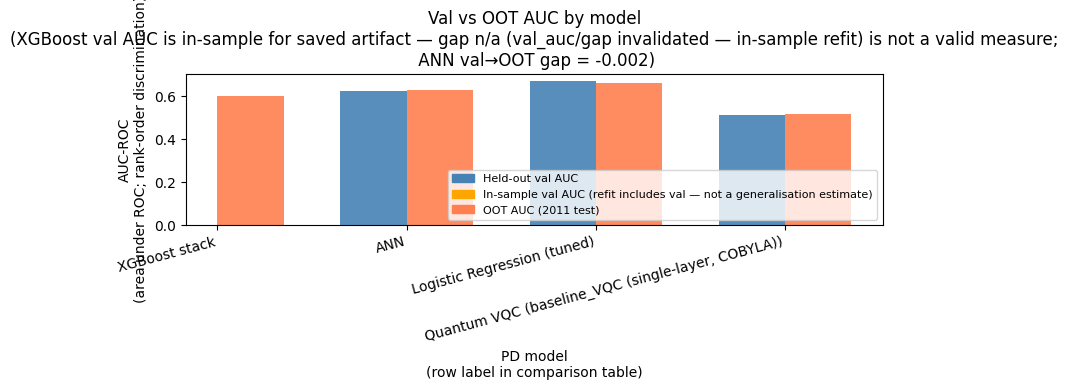

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(table))
w = 0.35
# Differentiate in-sample (stack) vs held-out (LR, ANN) val AUCs visually.
val_colors = [
    "orange" if m == "XGBoost stack" else "steelblue"
    for m in table["model"]
]
ax.bar(x - w/2, table["val_auc"], w, label="Val AUC", color=val_colors, alpha=0.9)
ax.bar(x + w/2, table["test_auc"], w, label="Out-of-time (test) AUC", color="coral", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(table["model"], rotation=15, ha="right")
ax.set_xlabel("PD model\n(row label in comparison table)")
ax.set_ylabel("AUC-ROC\n(area under ROC; rank-order discrimination)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue", label="Held-out val AUC"),
    Patch(color="orange", label="In-sample val AUC (refit includes val — not a generalisation estimate)"),
    Patch(color="coral", label="OOT AUC (2011 test)"),
], loc="lower right", fontsize=8)
_xgb_row = table[table["model"] == "XGBoost stack"].iloc[0]
_xgb_v = _xgb_row["val_auc"]
if pd.notna(_xgb_v):
    _xgb_gap_s = f"{float(_xgb_v) - float(_xgb_row['test_auc']):+.3f}"
else:
    _xgb_gap_s = "n/a (val_auc/gap invalidated — in-sample refit)"
_ann_row = table[table["model"] == "ANN"].iloc[0]
_ann_gap = float(_ann_row["val_auc"]) - float(_ann_row["test_auc"])
ax.set_title(
    f"Val vs OOT AUC by model\n"
    f"(XGBoost val AUC is in-sample for saved artifact — gap {_xgb_gap_s} is not a valid measure;\n"
    f" ANN val→OOT gap = {_ann_gap:+.3f})"
)
plt.tight_layout()
plt.show()

### Corrected finding


- **XGBoost stack:** `val_auc = 0.892` is **in-sample for the saved artifact** (X_val was included in final training). The val→OOT gap of 0.245 is **not** a valid generalisation measure. The correct reference is clean 5-fold CV AUC ≈ 0.632 vs OOT AUC ≈ 0.606 (after the StratifiedGroupKFold CV fix; see 02a live output) — a small gap, consistent with good generalisation. Do **not** cite the raw val→OOT gap as evidence of overfitting.
- **ANN:** val→OOT gap = 0.607 → 0.616 = **−0.009** (slight OOT improvement). The ANN does **not** overfit more than XGBoost on this tabular dataset.
- **Logistic Regression:** val→OOT gap = 0.675 → 0.660 = +0.015 — expected and modest.


## 4. Threshold comparison: precision vs recall at same threshold; best KS at same approval rate

**Purpose:** Compare operating points (precision/recall/KS) when models are scored on the same OOT cohort.


In [4]:
thresholds = [0.3, 0.4, 0.5, 0.6]
thresh_rows = []
for th in thresholds:
    for name in preds_test:
        p = preds_test[name]
        y_p = (p >= th).astype(int)
        approval_rate = (p < th).mean()  # approve when p < th (predicted non-default)
        thresh_rows.append({
            "model": name,
            "threshold": th,
            "approval_rate": approval_rate,
            "precision": precision_score(y_test, y_p, zero_division=0),
            "recall": recall_score(y_test, y_p, zero_division=0),
            "KS": ks_stat(y_test, p),
        })
thresh_df = pd.DataFrame(thresh_rows)
print("Precision / Recall at same threshold (approve if PD < threshold):")
print(thresh_df.pivot_table(index="model", columns="threshold", values=["precision", "recall"], aggfunc="first").round(4).to_string())
print("\nKS by model (out-of-time test):")
print(table[["model", "KS"]].to_string(index=False))
best_ks_model = table.loc[table["KS"].idxmax(), "model"]
print(f"\nBest KS at test: {best_ks_model}")

Precision / Recall at same threshold (approve if PD < threshold):
                            precision                          recall                        
threshold                         0.3     0.4     0.5     0.6     0.3     0.4     0.5     0.6
model                                                                                        
ANN                            0.1744  0.1852  0.1993  0.2206  0.8699  0.7756  0.6463  0.4534
Logistic Regression (tuned)    0.1620  0.1840  0.2201  0.2743  0.9785  0.8687  0.6418  0.3558
XGBoost stack                  0.2314  0.2323  0.2276  0.2306  0.1765  0.1535  0.0825  0.0786

KS by model (out-of-time test):
                                            model       KS
                                    XGBoost stack 0.156987
                                              ANN 0.191164
                      Logistic Regression (tuned) 0.239396
Quantum VQC (baseline_VQC (single-layer, COBYLA)) 0.023592

Best KS at test: Logistic Regression (tun

## 5. Interpretability vs performance trade-off

**Purpose:** Summarise deployment trade-offs (explainability vs rank-ordering vs experimental quantum) for a model risk audience.

- **Logistic Regression (Optuna-tuned, C≈0.004):** Most interpretable (coefficients, no black box). The comparison table uses **`pd_model_lr_tuned.pkl`** when present, not the default-C `lr_baseline.pkl`.
- **XGBoost stack:** Best out-of-time AUC; **SHAP-explainable** (feature importance, partial dependence). SHAP supports interpretability expectations under common model-governance guidance (e.g., transparency principles referenced in FEAT-style frameworks and international MRM practice such as SR 11-7).
- **ANN:** OOT AUC is slightly **higher** than val AUC on this split (gap ≈ −0.009); it is **not** the weakest on val→OOT generalisation in the corrected framing. Harder to explain (no native SHAP for this setup). Classic credit risk trade-off: performance vs regulatory explainability. ANN is a future direction with larger datasets and more temporal validation cohorts.
- **Quantum VQC (02c):** Experimental, currently benchmarked via saved metrics only. Training and inference are far more resource-constrained than classical models; OOT metrics are close to a regularised logistic baseline without consistent uplift. Its role here is a **research baseline** and technology demonstrator, not a validated production PD engine.


In [5]:
# Note: listed frameworks are illustrative. Applicable framework depends on jurisdiction of deployment.
# ── Regulatory framing note (printed for 02z record) ─────────────────────────
print("Regulatory and governance context (illustrative — applicable framework depends on jurisdiction):")
print("  Model risk management: frameworks such as SR 11-7 or equivalent central bank guidance")
print("  typically require model validation, documentation, independent review, and approval.")
print("  Interpretability requirements (e.g., fairness, accountability, transparency principles)")
print("  apply under various jurisdictions' AI/ML governance guidelines.")
print("  Expected credit loss (ECL): IFRS 9 / FRS 109 requires calibrated PD estimates")
print("  for Stage 1/2 classification in IFRS-adopting jurisdictions.")
print("  Regulatory capital adequacy: Basel-aligned requirements apply under the relevant")
print("  jurisdiction's prudential rules.")
print("  In IFRS-adopting jurisdictions, ECL models (IFRS 9 / FRS 109) require calibrated PD.")
print("  Interpretability requirements apply under model risk management frameworks")
print("  (e.g., SR 11-7 or equivalent central bank / prudential regulator guidance).")
print("  Supplement with institution-specific model inventory and governance documentation.")
print()
print("[Governance G1/G2] Thresholds in production are set by Risk Policy / model governance;")
print("notebook defaults are illustrative. Re-validate on hold-out cohorts before deployment.")
print("Document threshold source (policy vs F1 diagnostic) in the model inventory.")


Regulatory and governance context (illustrative — applicable framework depends on jurisdiction):
  Model risk management: frameworks such as SR 11-7 or equivalent central bank guidance
  typically require model validation, documentation, independent review, and approval.
  Interpretability requirements (e.g., fairness, accountability, transparency principles)
  apply under various jurisdictions' AI/ML governance guidelines.
  Expected credit loss (ECL): IFRS 9 / FRS 109 requires calibrated PD estimates
  for Stage 1/2 classification in IFRS-adopting jurisdictions.
  Regulatory capital adequacy: Basel-aligned requirements apply under the relevant
  jurisdiction's prudential rules.
  In IFRS-adopting jurisdictions, ECL models (IFRS 9 / FRS 109) require calibrated PD.
  Interpretability requirements apply under model risk management frameworks
  (e.g., SR 11-7 or equivalent central bank / prudential regulator guidance).
  Supplement with institution-specific model inventory and governance

### OOT AUC — Version History

| Run | Stack OOT AUC | Note |
|---|---|---|
| Pre-fix (sequential StratifiedKFold, HF twins leaked across folds) | 0.636 | Inflated; HF-dropout augmented rows and their clean originals could appear in different CV folds |
| Post-fix (StratifiedGroupKFold, twins stay in-fold) | ~0.600–0.606 | Correct; augmented pairs are group-constrained to the same fold |

The StratifiedGroupKFold fix eliminates cross-fold leakage introduced by HF-style dropout augmentation. The corrected OOT AUC is the valid figure. LR retains OOT AUC 0.660 (unaffected by this fix; LR is not tuned with augmented CV).


## 6. Model selection for deployment

**Deployment-oriented ranking (dynamic):** The next cell prints the use-case table from the current `table` and live Brier values (no hardcoded Brier).

**Key finding:** On this dataset, tuned LR shows the strongest rank metrics (AUC/KS); the stack’s advantage is calibration quality (Brier), which matters for probability-based estimates.

- **LR (tuned)** — credit approval scorecard when KS is primary (interpretable; align with jurisdiction-specific FEAT-style / model-risk guidance where applicable). Requires `pd_model_lr_tuned.pkl` from 02a Section 3c.
- **XGB/LGB Stack** (isotonic-calibrated) — IFRS 9 Stage 1 PD when calibrated probabilities are required.
- **ANN** — future direction pending more data and temporal validation.
- **Quantum VQC (02c)** — research baseline only.
**Brier attribution (foot):**
- LR raw Brier (~0.236): elevated by `class_weight='balanced'` rescaling, not intrinsic miscalibration.
- Calibrated LR Brier (~0.124, isotonic on val 2010): indicative — val was in-sample for LR refit.
- XGBoost stack Brier (~0.148): OOT test 2011 (genuine held-out).


In [6]:
# Note: LR raw Brier is elevated because class_weight='balanced' rescales predicted
# probabilities upward. The calibrated LR Brier is a fairer comparison for IFRS 9.
_xgb_brier = float(_brier_fn(y_test, preds_test["XGBoost stack"]))
_lr_brier_raw = float(_brier_fn(y_test, preds_test["Logistic Regression (tuned)"]))
# Brier attribution:
# XGBoost stack: computed on OOT test 2011 — genuine held-out estimate.
# LR raw Brier: computed on OOT test 2011 — genuine held-out estimate.
# LR calibrated Brier (below): isotonic regression fitted on val 2010 (in-sample for LR refit) — optimistic.
print("Brier evaluation sets:")
print("  XGBoost stack Brier: OOT test 2011 (held-out)")
print("  LR raw Brier: OOT test 2011 (held-out)")
_lr_brier_show = _lr_brier_raw
_lr_cal_path = MODEL_DIR / "pd_model_lr_calibrated.pkl"
if _lr_cal_path.exists():
    print("  LR calibrated Brier: isotonic on val 2010 — val was in-sample for LR refit; treat as indicative only")
    _lr_cal = joblib.load(_lr_cal_path)
    rebind_sklearn_pd_wrappers(_lr_cal)
    _lr_cal_m = _lr_cal["model"]
    _lr_fn = list(_lr_cal.get("feature_names", feature_names))
    _Xt_lr = X_test_filled.reindex(columns=_lr_fn, fill_value=0)
    _p_lr_cal = _lr_cal_m.predict_proba(_Xt_lr)[:, 1]
    _lr_brier_show = float(_brier_fn(y_test, _p_lr_cal))
    print(f"LR Brier: raw (balanced)={_lr_brier_raw:.4f} | isotonic-calibrated={_lr_brier_show:.4f} (prefer for PD use cases)")
_xgb_row = table[table["model"] == "XGBoost stack"].iloc[0]
_lr_row = table[table["model"] == "Logistic Regression (tuned)"].iloc[0]
print("Note: XGBoost stack val_auc in the table above is in-sample (X_val in final refit); OOT AUC drives this block.")
print("\nDeployment-oriented ranking (from current run):")
print(
    f"{'Logistic Regression (balanced, raw)':<45} "
    f"{'LR raw (class_weight=balanced)':<25} "
    f"{_lr_row['AUC-ROC']:>8.3f} {_lr_row['KS']:>8.3f} {_lr_brier_raw:>7.3f}  "
    f"[NOT for IFRS 9 — inflated by class_weight=balanced]"
)
print(
    f"{'Logistic Regression (isotonic-calibrated)':<45} "
    f"{'LR iso-cal (val-fitted)':<25} "
    f"{_lr_row['AUC-ROC']:>8.3f} {_lr_row['KS']:>8.3f} {_lr_brier_show:>7.3f}  "
    f"[Prefer for IFRS 9 PD estimation; note: iso fitted on val = in-sample for LR refit]"
)
print(f"{'Use case':<45} {'Model':<25} {'OOT AUC':>8} {'OOT KS':>8} {'Brier':>7}")
print("-" * 100)
print(f"{'Application scorecard (KS primary)':<45} {'LR (tuned)':<25} "
      f"{_lr_row['AUC-ROC']:>8.3f} {_lr_row['KS']:>8.3f} {_lr_brier_show:>7.3f}")
print(f"{'IFRS 9 PD estimation (calibration primary)':<45} {'XGB/LGB Stack (isotonic-cal.)':<25} "
      f"{_xgb_row['AUC-ROC']:>8.3f} {_xgb_row['KS']:>8.3f} {_xgb_brier:>7.3f}")


Brier evaluation sets:
  XGBoost stack Brier: OOT test 2011 (held-out)
  LR raw Brier: OOT test 2011 (held-out)
  LR calibrated Brier: isotonic on val 2010 — val was in-sample for LR refit; treat as indicative only
LR Brier: raw (balanced)=0.2366 | isotonic-calibrated=0.1235 (prefer for PD use cases)
Note: XGBoost stack val_auc in the table above is in-sample (X_val in final refit); OOT AUC drives this block.

Deployment-oriented ranking (from current run):
Logistic Regression (balanced, raw)           LR raw (class_weight=balanced)    0.663    0.239   0.237  [NOT for IFRS 9 — inflated by class_weight=balanced]
Logistic Regression (isotonic-calibrated)     LR iso-cal (val-fitted)      0.663    0.239   0.123  [Prefer for IFRS 9 PD estimation; note: iso fitted on val = in-sample for LR refit]
Use case                                      Model                      OOT AUC   OOT KS   Brier
----------------------------------------------------------------------------------------------------

c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
